# Conditional Continuous Normalizing flow


In [3]:
import orthojax as ojax ### easy orthogonal polynomials
from typing import List, Callable, Tuple
import equinox as eqx
import matplotlib.pyplot as plt
import jax
from jax import random as jr, numpy as jnp
from jaxtyping import Float, Array
from jax.scipy.stats import norm, multivariate_normal
import optax
from layers import NormalizingFlow
from functools import partial
import diffrax
from abc import ABC, abstractmethod
import numpy as np
key = jr.PRNGKey(42)

### Problem Setup

We're going to take a look at solving the 1D viscous Burgers' equation 

$$ \frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} = \nu \frac{\partial^2 u}{\partial x^2} $$

Where $u(x,t)$ is the velocity field and $\nu$ is the viscosity parameter. 

We view this as a forward model with 

$$ y = \mathcal{G}(\nu) + \epsilon, \quad \epsilon \sim \mathcal{N}(0,0.1 * \mathbb{I}), \quad \nu \sim \mathcal{N}(1,0.5)$$

And $\mathcal{G}$ as the solution operator which maps the viscosity to the solution $u(x,T;\nu)$ at time $T=0.3$ for a fixed initial condtion.

As such we have our prior as $\nu \sim \mathcal{N}(1,0.5)$, our likelihood as $p(y|\nu)$ and our posterior as $p(\nu|y)$. We aim to learn the posterior
of a quantity of interest which is a pushforward of the posterior. In other words, a conditional distribution

$$p(\text{qoi}|y) = \int p(\text{qoi}|x,y) p(x|y) dx$$

We take the $\text{qoi}$ to be the energy of the solution at a fixed time $u(x,t=0.3)$, which can be computed by taking the squared $\ell_2$ norm of the vector of coefficients associated with projecting it onto a sine basis. Our solver is coefficient-based anyways so this not an inconvienence. 

In [40]:
from burgers_solver import Viscous_Burgers_Spectral_Galerkin
n_prior_samples = 1000

np.random.seed(0)

n_modes = 100

### generate fixed initial condition
U0 = np.zeros([1, n_modes])
U0[:,1] = 1 

### final time step, prior over nu, time step size
t = 0.3
nu = np.random.uniform(0.1, 0.5, size=(n_prior_samples))
dt = 0.001

### solve for all nu samples
def solve(nu):
    U_soln = Viscous_Burgers_Spectral_Galerkin(nu, dt, int(t/dt), U0) ### 1, n_modes
    return U_soln

U_solns = []
for nu in nu:
    U_solns.append(solve(nu).squeeze())
U_soln = np.asarray(U_solns) ### n_prior_samples, n_modes

epsilon = np.random.randn(n_prior_samples, n_modes) * 0.1
y = U_soln + epsilon

qoi = energy = np.sum(U_soln**2, axis=-1)[:,None] ### (n_prior_samples,1) 
qoi_dim = z_dim = 1
y_dim = n_modes

### Base Distribution

In [41]:
class ConditionalDiagonalGaussianBaseDensity(eqx.Module):
    mu: eqx.Module
    Sig: eqx.Module
    def __init__(self, *, y_dim, z_dim, mu_func Sigma_func, key):
        keys = jr.split(key)
        self.mu = mu_funct(in_size=y_dim, out_size=z_dim, key=keys[0])
        self.Sig = Sigma_func(in_size=y_dim, out_size=z_dim, key=keys[1])
    def logpdf(self, z, y):
        return multivariate_normal.logpdf(z, mean=self.mu(y), cov=jnp.diag(jax.nn.softplus(self.Sig(y))))
    def rvs(self, y, key, shape):
        return jr.multivariate_normal(key, mean=self.mu(y), cov=jnp.diag(jax.nn.softplus(self.Sig(y))), shape=shape)

### ... or not
class FixedStandardNormal(eqx.Module):
    dim: int
    def __init__(self, *, dim,):
        self.dim = dim
    def logpdf(self, z, y):
        return multivariate_normal.logpdf(z, mean=jnp.zeros((self.dim,)), cov=jnp.eye(self.dim))
    def rvs(self, y, key, shape):
        return jr.multivariate_normal(key, mean=jnp.zeros((self.dim,)), cov=jnp.eye(self.dim), shape=shape)

key,_ = jr.split(key)
m_function = partial(eqx.nn.MLP, depth=1, width_size=16, activation=jax.nn.tanh)
S_function = partial(eqx.nn.MLP, depth=1, width_size=16, activation=jax.nn.tanh)
base_dist = ConditionalDiagonalGaussianBaseDensity(y_dim=y_dim,
                                                z_dim=z_dim,
                                                mu_function=m_function,
                                                Sig_function=S_function,
                                                key=key)

### Now Define Vector Field

In [42]:
### Base layer
class ConcatSquash(eqx.Module):
    lin1: eqx.nn.Linear
    lin2: eqx.nn.Linear
    lin3: eqx.nn.Linear

    def __init__(self, *, in_size, out_size, key):
        keys = jr.split(key, 3)
        self.lin1 = eqx.nn.Linear(in_size, out_size, key=keys[0])
        self.lin2 = eqx.nn.Linear(1, out_size, key=keys[1])
        self.lin3 = eqx.nn.Linear(1, out_size, use_bias=False, key=keys[2])

    def __call__(self, t, x):
        return self.lin1(x) * jax.nn.sigmoid(self.lin2(t)) + self.lin3(t)

### Compositional
class ConditionalVectorField(eqx.Module):
    layers: List[eqx.Module]
    def __init__(self, *, base_layer, data_size, cond_size, width_size, depth, key):
        layers = []
        keys = jr.split(key, depth+1)
        if depth == 0: layers.append(base_layer(in_size=data_size+cond_size, out_size=data_size, key=keys[0]))
        else:
            layers.append(base_layer(in_size=data_size+cond_size, out_size=width_size, key=keys[0]))
            [layers.append(base_layer(in_size=width_size+cond_size, out_size=width_size, key=k)) for k in keys[1:-1]]
            layers.append(base_layer(in_size=width_size+cond_size, out_size=data_size, key=keys[-1]))
        self.layers = layers
        
    def __call__(self, t, x, args):
        y = args[0]
        t = jnp.asarray(t)[None] ### make t shape (1,) vs scalar
        for layer in self.layers[:-1]:
            xy = jnp.concatenate((x,y))
            x = layer(t, xy)
            x = jax.nn.tanh(x)
            
        xy = jnp.concatenate((x,y))
        x = self.layers[-1](t, xy)
        return x


In [43]:
def approx_logp_wrapper(t, x, args):
    x, _ = x
    *args, eps, func = args
    fn = lambda x: func(t, x, args=args)
    f, vjp_fn = jax.vjp(fn, x)
    (eps_dfdx,) = vjp_fn(eps) ### e^T @ \nabla_x F
    logp = jnp.sum(eps_dfdy * eps)
    return f, logp

def exact_logp_wrapper(t, x, args):
    x, _ = x
    *args, func = args
    fn = lambda x: func(t, x, args=args)
    f, vjp_fn = jax.vjp(fn, x)
    (size,) = x.shape  # this implementation only works for 1D input
    eye = jnp.eye(size)
    (dfdx,) = jax.vmap(vjp_fn)(eye)
    logp = jnp.trace(dfdx)
    return f, logp    

### Model which does the solve!

In [44]:
adjoint = diffrax.RecursiveCheckpointAdjoint()

class ConditionalCNF(eqx.Module):
    Func: eqx.Module
    t0: float
    t1: float
    dt0: float
    ODETerm: diffrax.ODETerm
    solver: diffrax.AbstractSolver
    base_dist: Callable
    
    def __init__(self, *, Func, t0, t1, dt0, exact_logp, base_dist, key):
        key,_ = jr.split(key)
        self.Func = Func(key=key)
        self.t0, self.t1, self.dt0 = t0, t1, dt0
        if exact_logp: self.ODETerm = diffrax.ODETerm(exact_logp_wrapper)
        else: self.ODETerm = diffrax.ODETerm(approx_logp_wrapper)
            
        self.solver = diffrax.Tsit5()
        self.base_dist = base_dist
        
    def train(self, x, y, key):
        eps = jr.normal(key, x.shape)
        delta_log_likelihood = 0.0
        x = (x, delta_log_likelihood)
        sol = diffrax.diffeqsolve(
            self.ODETerm, 
            self.solver, 
            self.t1, 
            self.t0, 
            -self.dt0, 
            x, 
            args=(y, eps, self.Func),
            adjoint=adjoint,
        )
        (x,), (delta_log_likelihood,) = sol.ys
        logp_x = delta_log_likelihood + self.base_dist.logpdf(x, y)
        return x, logp_x

    def sample(self, key, y):
        x = self.base_dist.rvs(y, key=key, shape=())
        term = diffrax.ODETerm(self.Func)
        solver = diffrax.Tsit5()
        sol = diffrax.diffeqsolve(term, solver, self.t0, self.t1, self.dt0, x, args=(y,))
        (x,) = sol.ys
        return x
        

### Instantiate Model

In [45]:
key,_ = jr.split(key)

### could swap this to polynomial or kernel or whatever we want
base_layer = ConcatSquash

Func = partial(ConditionalVectorField, base_layer=base_layer, data_size=qoi_dim, cond_size=y_dim, width_size=32, depth=3)

model = ConditionalCNF(Func=Func, t0=0.0, t1=1.0, dt0=0.05, base_dist=base_dist, exact_logp=True, key=key)

### Training/Optimizer Configuration

In [46]:
epochs = 10000
lr_schedule = optax.schedules.cosine_onecycle_schedule(epochs, peak_value=1e-3)
opt = optax.adamw(lr_schedule, weight_decay=0.1)
opt_state = opt.init(eqx.filter(model, eqx.is_inexact_array))

In [47]:
@eqx.filter_jit
def train_step(model, opt_state, batch, batch_key):
    x, y = batch
    def nll(model):
        ### T is a function of x i.e. x_cond_y and y
        _, logp_x = jax.vmap(lambda x,y: model.train(x, y, batch_key))(x, y)
        return -jnp.mean(logp_x)
        
    loss, grads = eqx.filter_value_and_grad(nll)(model)
    updates, opt_state = opt.update(grads, opt_state, eqx.filter(model, eqx.is_inexact_array))
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss 


def sample_conditional(model, yi, key):
    keys = jr.split(key, 1000)
    x_cond_yi_samples = jax.vmap(lambda key: model.sample(key,yi))(keys) ### n_samples, q_dim
    return x_cond_yi_samples

@eqx.filter_jit
def eval(model, y, key):
    x_cond_y_samples = jax.vmap(lambda yi: sample_conditional(model, 
                                                              yi, key), 
                                out_axes=1)(y) ### n_samples, n_y, q_dim

    return x_cond_y_samples

### Loop

In [48]:
for epoch in range(100):
    key, epoch_key = jr.split(key)
    model, opt_state, loss = train_step(model, opt_state, (qoi, y), epoch_key)
    samples = eval(model, y, key) ### (n_samples, n_y, q_dim)
    if epoch % 1 == 0:
        print(f'{epoch=}, nll:{loss.item():.5f}')

epoch=0, nll:1.69384
epoch=1, nll:1.69292
epoch=2, nll:1.69200
epoch=3, nll:1.69109
epoch=4, nll:1.69017
epoch=5, nll:1.68926
epoch=6, nll:1.68835
epoch=7, nll:1.68743
epoch=8, nll:1.68652
epoch=9, nll:1.68561
epoch=10, nll:1.68470
epoch=11, nll:1.68379
epoch=12, nll:1.68288
epoch=13, nll:1.68197
epoch=14, nll:1.68106
epoch=15, nll:1.68015
epoch=16, nll:1.67925
epoch=17, nll:1.67834
epoch=18, nll:1.67743
epoch=19, nll:1.67653
epoch=20, nll:1.67562
epoch=21, nll:1.67472


KeyboardInterrupt: 

(array([  6.,  18.,  72., 174., 220., 234., 165.,  81.,  27.,   3.]),
 array([-2.87272191, -2.33275294, -1.79278409, -1.25281525, -0.71284628,
        -0.17287731,  0.36709142,  0.90706038,  1.44702935,  1.98699832,
         2.52696729]),
 <BarContainer object of 10 artists>)

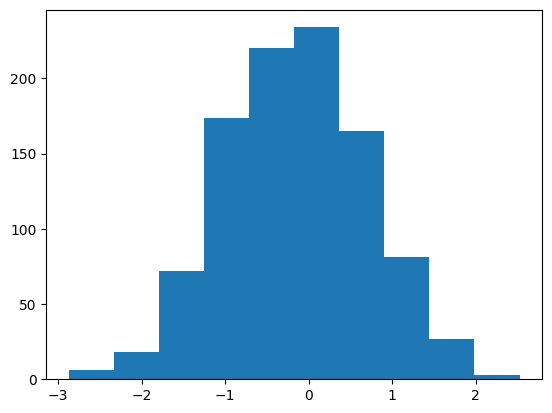

In [49]:
plt.hist(samples[:,0,0])